## Training and Visualizing Decision Trees

In [11]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()
X = iris.data[:, 2:] #petal length and width
y = iris.target

tree_clf = DecisionTreeClassifier(max_depth = 2)
tree_clf.fit(X, y)

DecisionTreeClassifier(max_depth=2)

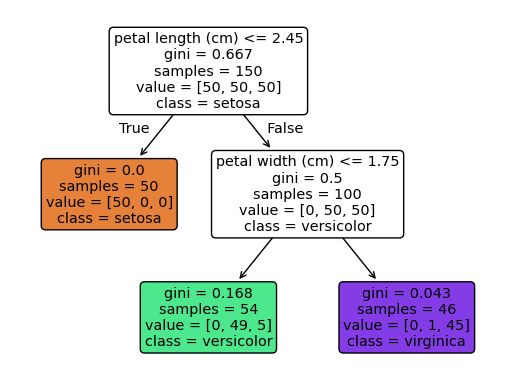

In [12]:
from sklearn.tree import plot_tree
result = plot_tree(tree_clf, rounded = True, filled = True, class_names = iris.target_names, feature_names = iris.feature_names[2:])

__Notes:__ 
* A nice advantage of decision trees is that they don't require much data preparation. They don't even need data scaling or centering!
* The "samples" field in the decision tree tells you how many samples from the training set this condition applies to.
* The value attribute tells you how many instances from each class the condition applies to.
* The gini attribute measures the _impurity_ of the values. It is calculated as follows:
    $G_i = 1 - \sum_{k = 1}^{n}p_{i, k}^2$

    $p_{i, k}^2$ is the value attribute divided by the number of samples.

    For example, the depth-2 left node is calculated as follows:
    
    $1 - (\frac{0}{54})^2 - (\frac{49}{54})^2 - (\frac{5}{54})^2 = 0.168$

* Scikit-learn uses the CART algorithm, which allows each nonleaf node to have only two childred (allows for yes or no questions only), but there exists other alogrithms that allows for more children such as ID3.

* Decision trees are generally called a _white box model_ since their interpretation is easy and intuitive. On the other hand, neural networks and random forests are called a _black box model_ since it is hard to understand how they come up with their predictions.

* Decision trees are also able to output class probabilities by determining which leaf node the instance likely blongs to, and then it divides the value attribute by the samples attribute to get the probability of each class for that leaf node. It is also worth mentioning that as long as the instance lands in the same leaf node, the output probability will be the same even if we change the input features slightly.



### The CART Training Algorithm
CART (Classification and Regression Tree) algorithm is used by scikit-learn to train decision trees. The algorithm works by splitting the training set in half using a single feature $k$ and a threshold $t_k$. 

The way it chooses the feature and the threshold is that it searches for the pair ($k$, $t_k$) that gives the purest subsets according to the following cost function:

$J(k, t_k) = \frac{m_{left}}{m}G_{left} + \frac{m_{right}}{m}G_{right}$

Where:
$G_{left/right}$ measures the impurity of the left/right subset.

$m_{left/right}$ is the number of instances in the left/right subset.

The CART algorithm continues to split the training set in this way until the max_depth is reached, or it cannot find a split that can reduce the cost. 

The CART algorithm is a greedy algorithm. This means that it finds the optimum split at the top level, without checking if this will lead to better splits down the road. This characterstic produces a good enough solution to the problem, but it is not guaranteed to be the optimal solution. If we want to find the optimal solution, then the time complexity of such algorithm would be O(exp(m)), which makes it infeasible to do so even on small datasets. 

The prediction time complexity is rougly equal to $O(log_2(m))$.

The training complexity is roughly equal to $O(n*m*log_2(m))$.

You can choose to train the decision tree either using the gini impurity or entropy by setting the criterion hyperparameter to 'entropy'.

The equation for entropy is:

$H_i = -\sum_{k = 1}^{n}(log_2(P_{i,k})),\ P_{i,k}\neq0$

It doesn't really matter if you choose to use the gini impurity or entropy since they lead to similar trees. The main difference between them is that the gini impurity is slightly faster to compute, which makes it a good default. However, the gini impurity tends to isolate the most frequent class in its own branch of the tree, while entropy produces a more balanced tree.  

### Regularization hyperparamters
Decision trees can easily overfit the data if left unconstrained since they follow the training data closely. 

Decision trees are usually called a _nonparamteric model_ because the number of paramters the model uses is not determined prior to training, which means that the model is free to stick to the data closely. On the other hand, a _parametric model_ has a pre-determined number of paramters, so its degree of freedom is limited. 

Here is a list of a few paramters that can reduce the risk of overfitting when training decision trees:
1. min_samples_split: the minimum number of samples a node must have before it can split.
2. min_samples_leaf: the minimum number of samples a leaf node must have.
3. min_weight_fraction_leaf: same as min_samples_leaf, but expressed as a fraction of the total number of weighted instances.
4. max_leaf_nodes: the maximum number of leaf nodes.
5. max_depth: the maximum depth of the tree.
6. max_features: the maximum number of features that are evaluated for splitting each node.

__Note:__ Increasing the hyperparamters that begin with min_ or reducing the max_ hyperparamters will regularize the model. 